In [23]:
from sklearn.preprocessing import StandardScaler
import gower
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score
import pandas as pd
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import squareform
from sklearn.manifold import TSNE
from sklearn.cluster import Birch
from sklearn.decomposition import PCA
#import ace_tools_open as tools
import gower
import numpy as np
import pandas as pd
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import fcluster
#from ace_tools import display_dataframe_to_user
from sklearn.preprocessing import StandardScaler
import gower
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt

import pandas as pd
import gower
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import gower
from scipy.cluster.hierarchy import linkage, fcluster

In [5]:
#Downloaing the dataset:
df = pd.read_excel("receipts.xlsx")  
df.head()


,Paid Amount,is delivery,is_morning,is_afternoon,is_evening,ratio_kebab,ratio_combo,ratio_drink,ratio_other
0,182.0,0,1,0,0,0.851648,0.0,0.148352,0.000000
1,691.0,0,1,0,0,0.821997,0.0,0.053546,0.124457
2,142.0,0,1,0,0,1.000000,0.0,0.000000,0.000000
3,273.0,1,1,0,0,1.000000,0.0,0.000000,0.000000
4,438.0,1,1,0,0,0.785388,0.0,0.214612,0.000000


In [9]:
#Defining the set and data scaling
try:
    from IPython.display import display
except ImportError:
    display = print

numeric_cols = [
    "Paid Amount",
    "ratio_kebab", "ratio_combo", "ratio_drink", "ratio_other"
]

feature_sets = {
    "set1": [
        "Paid Amount", "is delivery",
        "is_morning", "is_afternoon", "is_evening",
        "ratio_kebab", "ratio_combo", "ratio_drink", "ratio_other"
    ]
}
def scale_numeric_columns(df, numeric_cols):
    scaler = StandardScaler()
    df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
    return df


/var/folders/h0/6sfpzyd51qq4hn4k6fzpnwt40000gn/T/ipykernel_55416/728584184.py:8: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance_matrix, method='average')


,Feature Set,Num Clusters,Silhouette Score
0,"Paid Amount, is delivery, is_morning, is_after...",5,0.564336
1,"Paid Amount, is delivery, is_morning, is_after...",6,0.642502
2,"Paid Amount, is delivery, is_morning, is_after...",7,0.639996
3,"Paid Amount, is delivery, is_morning, is_after...",8,0.638334
4,"Paid Amount, is delivery, is_morning, is_after...",9,0.641461
5,"Paid Amount, is delivery, is_morning, is_after...",10,0.642381
6,"Paid Amount, is delivery, is_morning, is_after...",11,0.635686


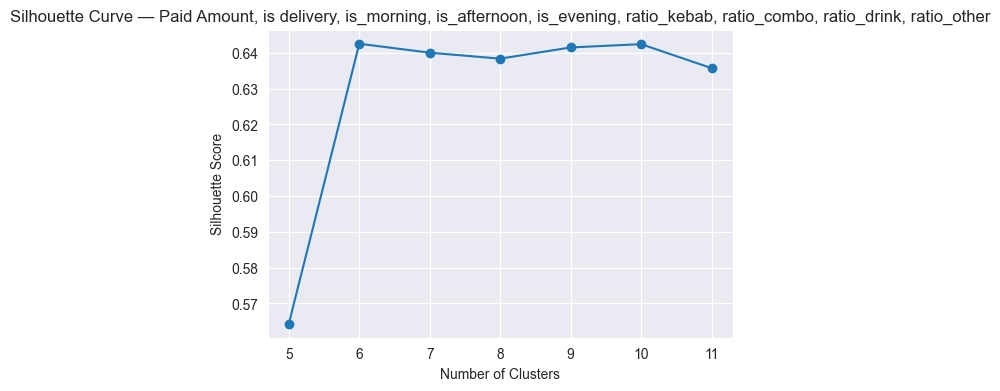

In [10]:
#Silhouette score and curve
def evaluate_hierarchical_gower(df, features, cluster_range=(5, 11)):
    results = []
    X = df[features]
    # compute Gower distance matrix
    distance_matrix = gower.gower_matrix(X)
    # linkage once with average method
    Z = linkage(distance_matrix, method='average')
    for k in range(cluster_range[0], cluster_range[1] + 1):
        labels = fcluster(Z, t=k, criterion='maxclust')
        sil = silhouette_score(distance_matrix, labels, metric='precomputed')
        results.append({
            "Feature Set": ", ".join(features),
            "Num Clusters": k,
            "Silhouette Score": sil
        })
    return results

df_scaled = scale_numeric_columns(df.copy(), numeric_cols)

all_results = []
for name, feats in feature_sets.items():
    all_results.extend(evaluate_hierarchical_gower(df_scaled, feats))

results_df = pd.DataFrame(all_results)

display(results_df)

for feat_set in results_df["Feature Set"].unique():
    subset = results_df[results_df["Feature Set"] == feat_set]
    plt.figure(figsize=(6, 4))
    plt.plot(subset["Num Clusters"], subset["Silhouette Score"], marker='o')
    plt.xlabel("Number of Clusters")
    plt.ylabel("Silhouette Score")
    plt.title(f"Silhouette Curve — {feat_set}")
    plt.grid(True)
    plt.show()


/var/folders/h0/6sfpzyd51qq4hn4k6fzpnwt40000gn/T/ipykernel_55416/289081284.py:3: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance_matrix, method='average')


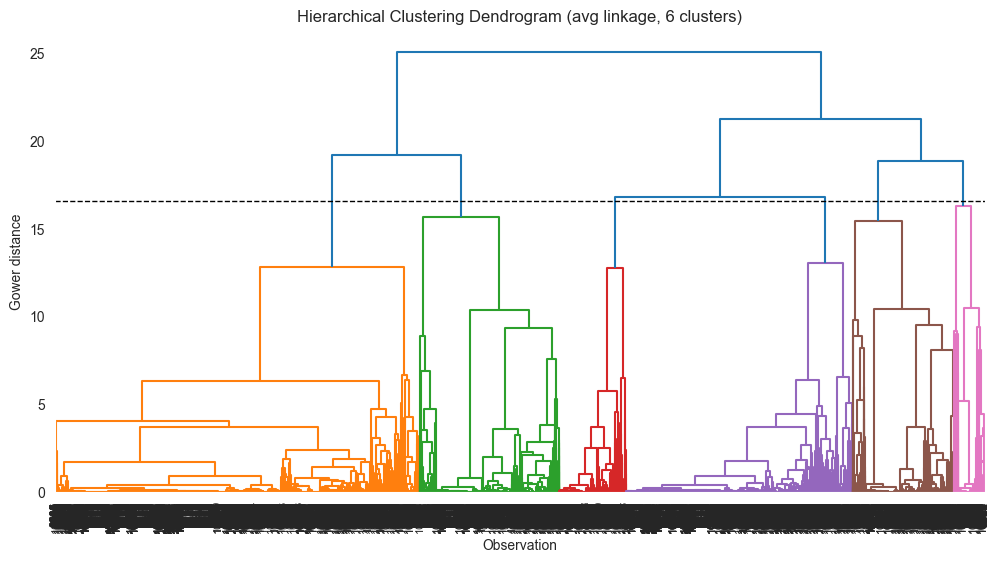

In [11]:
#Hierarchical Clustering Dendrogram for method linkage
distance_matrix = gower.gower_matrix(df_scaled[feature_sets['set1']])
Z = linkage(distance_matrix, method='average')

num_clusters = 6

threshold = (Z[-num_clusters,    2] + 
             Z[-(num_clusters-1),2]) / 2

plt.figure(figsize=(12, 6))
dendrogram(
    Z,
    color_threshold=threshold,
    leaf_rotation=90,
    leaf_font_size=8,
    labels=df_scaled.index.astype(str).tolist()
)
plt.axhline(y=threshold, color='black', linestyle='--', linewidth=1)
plt.title(f'Hierarchical Clustering Dendrogram (avg linkage, {num_clusters} clusters)')
plt.xlabel('Observation')
plt.ylabel('Gower distance')
plt.show()

In [12]:
#Display min,max,mean,madian
optimal_k = 6
df_scaled["Cluster"] = fcluster(Z, t=optimal_k, criterion="maxclust")

cluster_summary = (
    df_scaled
      .groupby("Cluster")[feature_sets["set1"]]
      .agg(["min", "max", "mean", "median"])
)

cluster_summary["Count"] = df_scaled["Cluster"].value_counts().sort_index()

cluster_summary

Paid Amount                                is delivery                \
                min        max      mean    median         min max      mean   
Cluster                                                                        
1         -0.635336  10.191859  0.114829 -0.234077           0   1  0.052218   
2         -1.519467   6.288084 -0.294314 -0.710147           0   1  0.113128   
3         -0.635336   4.193375  0.098301 -0.220475           0   1  0.092522   
4         -0.635336   7.083801  0.139784 -0.213674           0   1  0.074115   
5         -1.519467   9.705927 -0.276012 -0.764555           0   1  0.124378   
6         -1.519467   7.954329 -0.360468 -1.050197           0   1  0.127072   

               is_morning      ... ratio_combo ratio_drink            \
        median        min max  ...      median         min       max   
Cluster                        ...                                     
1          0.0          0   0  ...    -0.34189   -0.473062  1.062445   
2          0.0          0   0  ...    -0.34189   -0.473062  2.809085   
3          0.0          1   1  ...    -0.34189   -0.473062  0.719039   
4          0.0          0   0  ...    -0.34189   -0.473062  0.995603   
5          0.0          0   0  ...    -0.34189   -0.473062  2.809085   
6          0.0          1   1  ...    -0.34189   -0.473062  2.809085   

                            ratio_other                               Count  
             mean    median         min       max      mean    median        
Cluster                                                                      
1       -0.308069 -0.473062   -0.384391  1.908753 -0.274998 -0.384391  4328  
2        0.712826 -0.473062   -0.384391  3.423296  0.673666 -0.384391  1653  
3       -0.295580 -0.473062   -0.384391  1.715529 -0.289407 -0.384391   789  
4       -0.343132 -0.473062   -0.384391  1.833026 -0.264896 -0.384391  2685  
5        0.718675 -0.473062   -0.384391  3.423296  0.748725 -0.384391  1206  
6        1.223269  2.809085   -0.384391  3.423296  0.312836 -0.384391   362  

[6 rows x 37 columns]

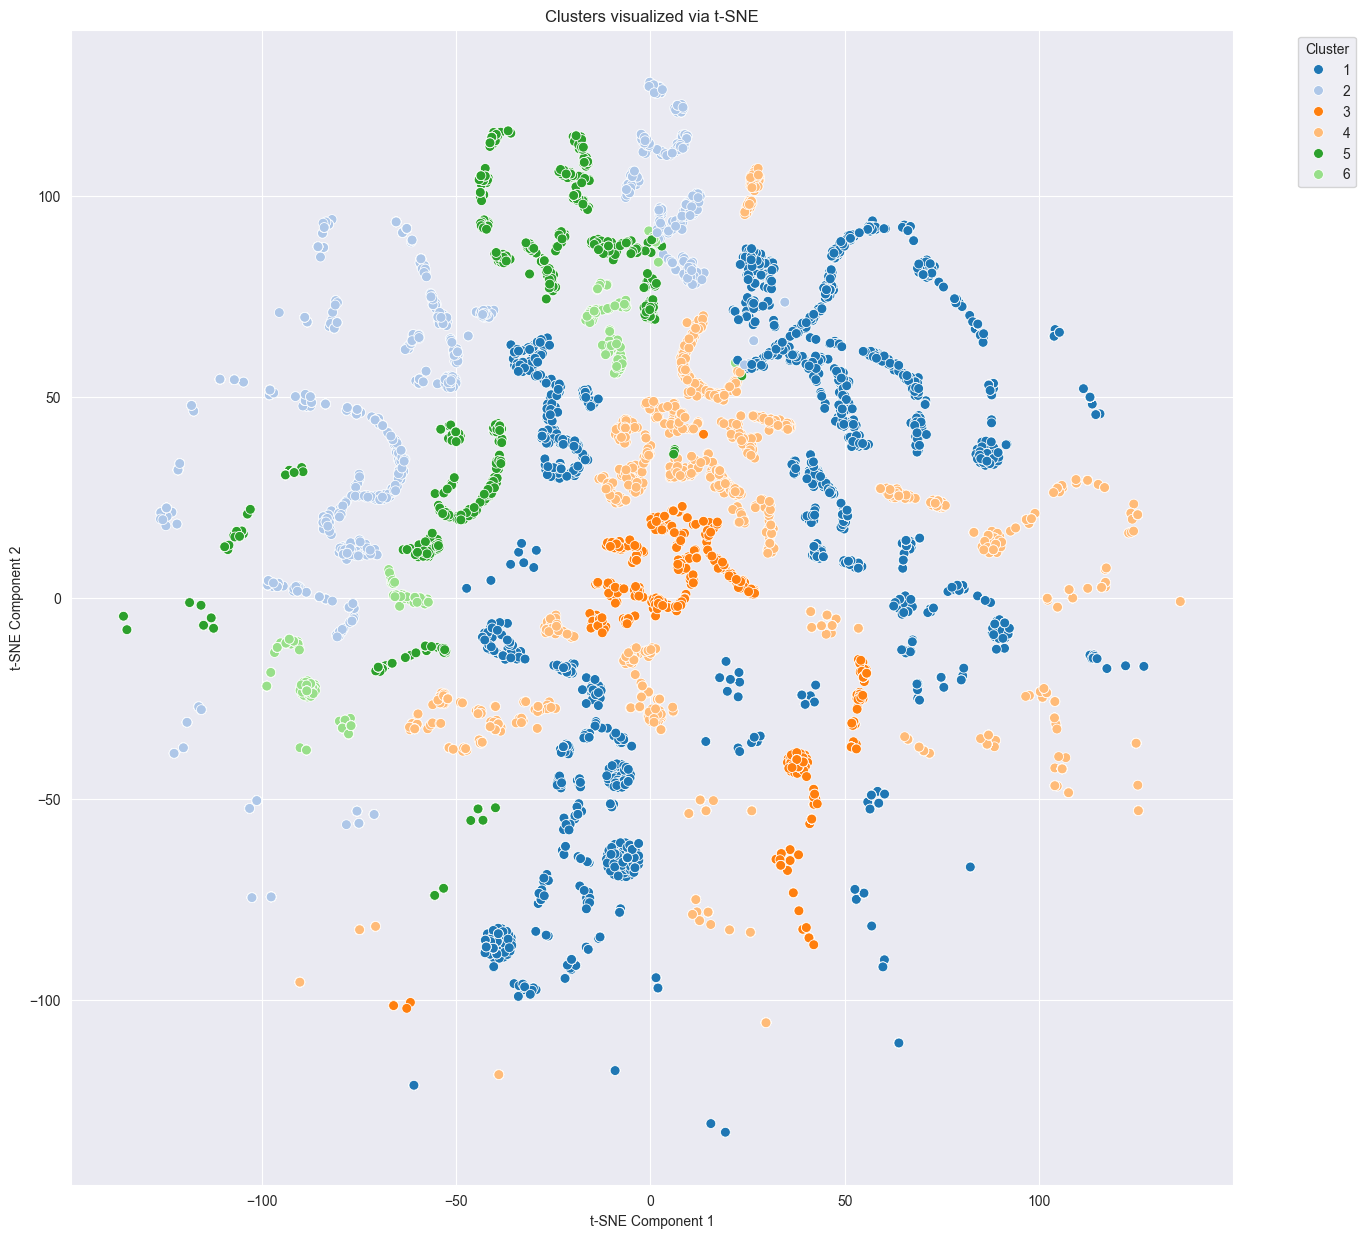

In [13]:
#Visualization via t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(df_scaled[feature_sets['set1']])

df_scaled['t-SNE_1'] = X_tsne[:, 0]
df_scaled['t-SNE_2'] = X_tsne[:, 1]

palette = sns.color_palette("tab20", 6)

plt.figure(figsize=(15, 15))
sns.scatterplot(
    data=df_scaled,
    x='t-SNE_1', y='t-SNE_2',
    hue='Cluster',
    palette=palette,
    s=50,
    legend="full"
)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("Clusters visualized via t-SNE")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


In [15]:
#Calculation of silhouette score, calinski harabasz, 
X = df_scaled[feature_sets['set1']]
distance_matrix = gower.gower_matrix(X)
Z = linkage(distance_matrix, method='average')

num_clusters = 6

threshold = (Z[-num_clusters,    2] +
             Z[-(num_clusters-1),2]) / 2

labels = fcluster(Z, t=threshold, criterion='distance')

sil = silhouette_score(distance_matrix, labels, metric='precomputed')
ch  = calinski_harabasz_score(X, labels)
db  = davies_bouldin_score(X, labels)

df_scores = pd.DataFrame([{
    'Method':              f'Agglomerative (Gower, avg; k={num_clusters})',
    'silhouette score':    round(sil, 2),
    'calinski harabasz':   round(ch, 2),
    'davies bouldin':      round(db, 2),
}])

print(df_scores.to_markdown(index=False))


/var/folders/h0/6sfpzyd51qq4hn4k6fzpnwt40000gn/T/ipykernel_55416/2556561910.py:4: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance_matrix, method='average')


| Method                          |   silhouette score |   calinski harabasz |   davies bouldin |
|:--------------------------------|-------------------:|--------------------:|-----------------:|
| Agglomerative (Gower, avg; k=6) |               0.64 |             1473.79 |             2.66 |


/var/folders/h0/6sfpzyd51qq4hn4k6fzpnwt40000gn/T/ipykernel_55416/2921163426.py:6: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance_matrix, method='ward')


,Feature Set,Num Clusters,Silhouette Score
0,"Paid Amount, is delivery, is_morning, is_after...",5,0.606473
1,"Paid Amount, is delivery, is_morning, is_after...",6,0.607929
2,"Paid Amount, is delivery, is_morning, is_after...",7,0.650905
3,"Paid Amount, is delivery, is_morning, is_after...",8,0.658206
4,"Paid Amount, is delivery, is_morning, is_after...",9,0.685391
5,"Paid Amount, is delivery, is_morning, is_after...",10,0.692043
6,"Paid Amount, is delivery, is_morning, is_after...",11,0.667838


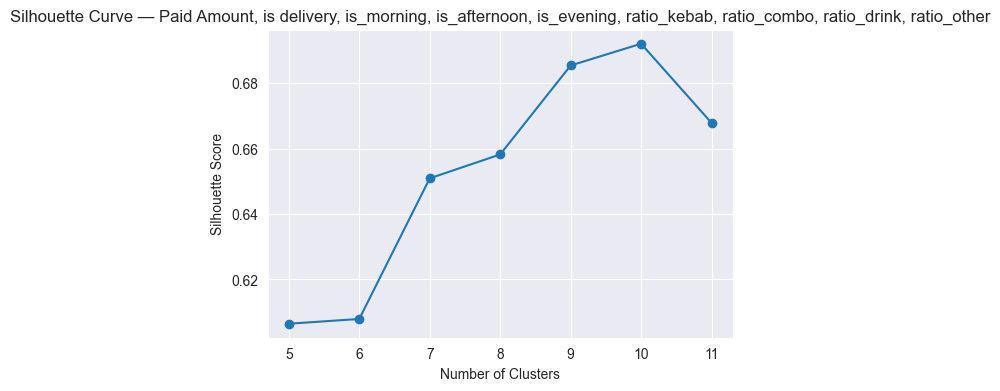

In [16]:
#Agglomerative clustering using Ward’s method and Plotting silhouette curves
def evaluate_hierarchical_gower(df, features, cluster_range=(5, 11)):
    results = []
    X = df[features]
    distance_matrix = gower.gower_matrix(X)
    Z = linkage(distance_matrix, method='ward')
    for k in range(cluster_range[0], cluster_range[1] + 1):
        labels = fcluster(Z, t=k, criterion='maxclust')
        sil = silhouette_score(distance_matrix, labels, metric='precomputed')
        results.append({
            "Feature Set": ", ".join(features),
            "Num Clusters": k,
            "Silhouette Score": sil
        })
    return results

df_scaled = scale_numeric_columns(df.copy(), numeric_cols)

all_results = []
for name, feats in feature_sets.items():
    all_results.extend(evaluate_hierarchical_gower(df_scaled, feats))

results_df = pd.DataFrame(all_results)

display(results_df)

for feat_set in results_df["Feature Set"].unique():
    subset = results_df[results_df["Feature Set"] == feat_set]
    plt.figure(figsize=(6, 4))
    plt.plot(subset["Num Clusters"], subset["Silhouette Score"], marker='o')
    plt.xlabel("Number of Clusters")
    plt.ylabel("Silhouette Score")
    plt.title(f"Silhouette Curve — {feat_set}")
    plt.grid(True)
    plt.show()

/var/folders/h0/6sfpzyd51qq4hn4k6fzpnwt40000gn/T/ipykernel_55416/1046390669.py:6: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance_matrix, method='ward')


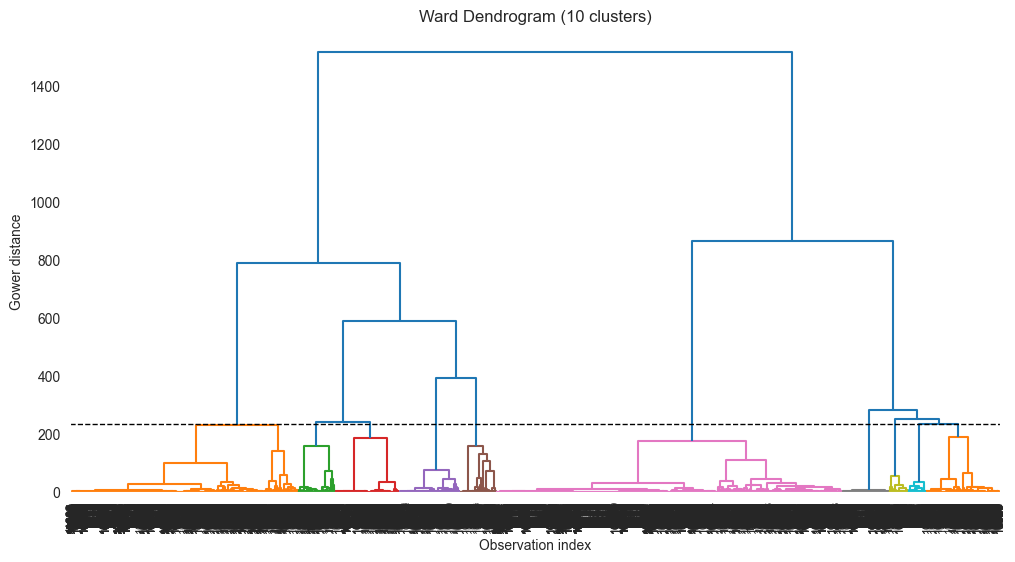

In [18]:
#Plotting dendrogram for Ward method
def plot_ward_dendrogram(df, features, num_clusters=10):
    X = df[features]
    distance_matrix = gower.gower_matrix(X)

    Z = linkage(distance_matrix, method='ward')

    idx = Z.shape[0] - num_clusters
    threshold = (Z[idx, 2] + Z[idx + 1, 2]) / 2
    plt.figure(figsize=(12, 6))
    dendrogram(
        Z,
        color_threshold=threshold,
        leaf_rotation=90,
        leaf_font_size=8,
        labels=df.index.astype(str).to_list()
    )
    plt.axhline(y=threshold, color='black', linestyle='--', linewidth=1)

    plt.title(f'Ward Dendrogram ({num_clusters} clusters)')
    plt.xlabel('Observation index')
    plt.ylabel('Gower distance')
    plt.show()

plot_ward_dendrogram(
    df_scaled,
    feature_sets["set1"],
    num_clusters=10
)

In [19]:
#Calculation of min,max,mean,madian for Agglomerative clustering with Ward method for optimal 10 clusters
optimal_k = 10
df_scaled["Cluster"] = fcluster(Z, t=optimal_k, criterion="maxclust")

cluster_summary = (
    df_scaled
      .groupby("Cluster")[feature_sets["set1"]]
      .agg(["min", "max", "mean", "median"])
)
cluster_summary["Count"] = df_scaled["Cluster"].value_counts().sort_index()

cluster_summary

Paid Amount                                is delivery                \
                min        max      mean    median         min max      mean   
Cluster                                                                        
1         -0.635336  10.191859  0.114829 -0.234077           0   1  0.052218   
2         -0.961784   5.682794  1.234584  0.881287           1   1  1.000000   
3         -1.519467   6.288084 -0.489337 -0.968585           0   0  0.000000   
4         -0.635336   4.193375  0.098301 -0.220475           0   1  0.092522   
5         -0.635336   6.022845  0.065331 -0.281684           0   0  0.000000   
6         -0.349694   7.083801  1.069889  0.908491           1   1  1.000000   
7         -0.839366   9.705927  1.371176  0.993504           1   1  1.000000   
8         -1.519467   5.839217 -0.509988 -0.968585           0   0  0.000000   
9         -0.424505   7.954329  1.951343  1.242862           1   1  1.000000   
10        -1.519467   5.573978 -0.696997 -1.145411           0   0  0.000000   

               is_morning      ... ratio_combo ratio_drink            \
        median        min max  ...      median         min       max   
Cluster                        ...                                     
1          0.0          0   0  ...   -0.341890   -0.473062  1.062445   
2          1.0          0   0  ...    3.205740   -0.473062 -0.043366   
3          0.0          0   0  ...   -0.341890   -0.473062  2.809085   
4          0.0          1   1  ...   -0.341890   -0.473062  0.719039   
5          0.0          0   0  ...   -0.341890   -0.473062  0.995603   
6          1.0          0   0  ...   -0.341890   -0.473062  0.594488   
7          1.0          0   0  ...    2.917495   -0.473062  1.101029   
8          0.0          0   0  ...   -0.341890   -0.473062  2.809085   
9          1.0          1   1  ...    2.929848   -0.473062 -0.058475   
10         0.0          1   1  ...   -0.341890   -0.473062  2.809085   

                            ratio_other                               Count  
             mean    median         min       max      mean    median        
Cluster                                                                      
1       -0.308069 -0.473062   -0.384391  1.908753 -0.274998 -0.384391  4328  
2       -0.464715 -0.473062   -0.384391  3.423296  0.043824 -0.384391   187  
3        0.863030 -0.473062   -0.384391  3.423296  0.754008 -0.384391  1466  
4       -0.295580 -0.473062   -0.384391  1.715529 -0.289407 -0.384391   789  
5       -0.340592 -0.473062   -0.384391  1.833026 -0.277983 -0.384391  2486  
6       -0.374856 -0.473062   -0.384391  1.616258 -0.101402 -0.384391   199  
7       -0.452810 -0.473062   -0.384391  3.423296  0.419871 -0.103142   150  
8        0.885079 -0.473062   -0.384391  3.423296  0.795437 -0.384391  1056  
9       -0.455555 -0.473062   -0.384391  3.423296  0.146038 -0.115823    46  
10       1.467654  2.809085   -0.384391  3.423296  0.337116 -0.384391   316  

[10 rows x 37 columns]

/var/folders/h0/6sfpzyd51qq4hn4k6fzpnwt40000gn/T/ipykernel_55416/1240265801.py:12: UserWarning: 
The palette list has fewer values (6) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(


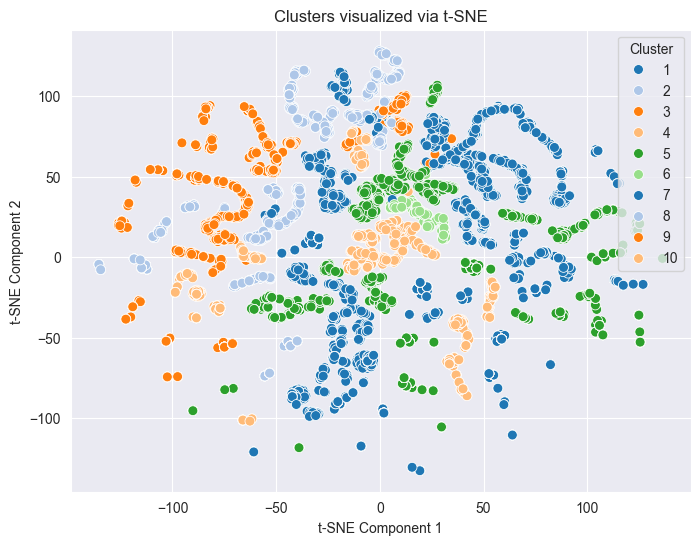

In [20]:
#Vsualization of 10 clusters via t-SNE for Agglomerative clustering with Ward method
optimal_k = 10
df_scaled['Cluster'] = fcluster(Z, t=optimal_k, criterion='maxclust')

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(df_scaled[feature_sets['set1']])

df_scaled['t-SNE_1'] = X_tsne[:, 0]
df_scaled['t-SNE_2'] = X_tsne[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_scaled,
    x='t-SNE_1', y='t-SNE_2',
    hue='Cluster',
    palette=palette,
    s=50,
    legend="full"
)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("Clusters visualized via t-SNE")
plt.legend(title="Cluster")
plt.show()

In [21]:
#Computing metrix: silhouette score, calinski harabasz, davies bouldin
X = df_scaled[feature_sets['set1']]
distance_matrix = gower.gower_matrix(X)
Z = linkage(distance_matrix, method='ward')

num_clusters = 10
threshold = (Z[-num_clusters,    2] +
             Z[-(num_clusters-1),2]) / 2

labels = fcluster(Z, t=threshold, criterion='distance')

sil = silhouette_score(distance_matrix, labels, metric='precomputed')
ch  = calinski_harabasz_score(X, labels)
db  = davies_bouldin_score(X, labels)

df_scores = pd.DataFrame([{
    'Method':              f'Agglomerative (Gower, ward; k={num_clusters})',
    'silhouette score':    round(sil, 2),
    'calinski harabasz':   round(ch, 2),
    'davies bouldin':      round(db, 2),
}])

print(df_scores.to_markdown(index=False))


/var/folders/h0/6sfpzyd51qq4hn4k6fzpnwt40000gn/T/ipykernel_55416/401908659.py:4: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(distance_matrix, method='ward')


| Method                            |   silhouette score |   calinski harabasz |   davies bouldin |
|:----------------------------------|-------------------:|--------------------:|-----------------:|
| Agglomerative (Gower, ward; k=10) |               0.69 |                1855 |             1.74 |


In [24]:
#Calculation of min,max,mean,median for rescaled data
def scale_numeric_columns(df, numeric_cols):
    scaler = StandardScaler()
    df_scaled = df.copy()
    df_scaled[numeric_cols] = scaler.fit_transform(df_scaled[numeric_cols])
    return df_scaled, scaler

def reverse_scaling(df_scaled, numeric_cols, scaler):
    df_orig = df_scaled.copy()
    df_orig[numeric_cols] = scaler.inverse_transform(df_orig[numeric_cols])
    return df_orig

def hierarchical_clustering(df, features, num_clusters=10):
    X = df[features]
    D = gower.gower_matrix(X)
    Z = linkage(D, method='ward')
    df["Cluster"] = fcluster(Z, t=num_clusters, criterion='maxclust')
    return df, Z

df_scaled, scaler = scale_numeric_columns(df.copy(), numeric_cols)

df_scaled, Z = hierarchical_clustering(df_scaled, feature_sets['set1'], num_clusters=10)

cluster_summary_scaled = (
    df_scaled
      .groupby("Cluster")[numeric_cols]
      .agg(["min", "max", "mean", "median"])
)
cluster_summary_scaled["Count"] = df_scaled.groupby("Cluster").size().sort_index()
print("Cluster feature statistics (min, max, mean, median) in scaled space:")
print(cluster_summary_scaled)

df_rescaled = reverse_scaling(df_scaled, numeric_cols, scaler)

cluster_stats_rescaled = (
    df_rescaled
      .groupby("Cluster")[numeric_cols]
      .agg(["min", "max", "mean", "median"])
)
cluster_stats_rescaled["Count"] = df_rescaled.groupby("Cluster").size().sort_index()

print("\nCluster feature statistics (min, max, mean, median) on original scale:")
print(cluster_stats_rescaled)


/var/folders/h0/6sfpzyd51qq4hn4k6fzpnwt40000gn/T/ipykernel_55416/3563745806.py:15: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(D, method='ward')


Cluster feature statistics (min, max, mean, median) in scaled space:
        Paid Amount                                ratio_kebab            \
                min        max      mean    median         min       max   
Cluster                                                                    
1         -0.635336   7.083801  0.156717 -0.200072   -0.815971  0.798057   
2         -0.839366   9.705927  0.923850  0.575242   -1.539170 -0.126773   
3         -1.519467   1.064914 -1.040576 -1.281431   -1.539170 -1.539170   
4         -0.635336   4.193375  0.050736 -0.247679   -0.751735  0.798057   
5         -1.519467   7.954329 -0.208767 -0.805361   -1.539170  0.798057   
6         -0.635336  10.191859  0.082473 -0.288485   -0.735571  0.798057   
7         -1.369844  -0.166067 -1.234538 -1.301834   -1.539170 -1.539170   
8         -0.383699   8.273976  0.807108  0.405217   -0.584609  0.798057   
9         -0.961784   5.682794  1.234584  0.881287   -1.539170 -0.609098   
10        -1.519467

In [25]:
#Calculation of min,max,mean,median for rescaled data
df_rescaled = reverse_scaling(df_scaled, numeric_cols, scaler)

cluster_stats_rescaled = (
    df_rescaled
      .groupby("Cluster")[numeric_cols]
      .agg(["min", "max", "mean", "median"])
)
cluster_stats_rescaled["Count"] = df_rescaled.groupby("Cluster").size().sort_index()

print("Cluster feature statistics (min, max, mean, median) on original scale:")
cluster_stats_rescaled

Cluster feature statistics (min, max, mean, median) on original scale:


Paid Amount                             ratio_kebab            \
                min      max        mean median         min       max   
Cluster                                                                 
1             135.0  1270.00  251.461255  199.0    0.309426  1.000000   
2             105.0  1655.55  364.258329  313.0    0.000000  0.604305   
3               5.0   385.00   75.414667   40.0    0.000000  0.000000   
4             135.0   845.00  235.878116  192.0    0.336910  1.000000   
5               5.0  1398.00  197.721562  110.0    0.000000  1.000000   
6             135.0  1727.00  240.544658  186.0    0.343826  1.000000   
7              27.0   204.00   46.895018   37.0    0.000000  0.000000   
8             172.0  1445.00  347.092920  288.0    0.408416  1.000000   
9              87.0  1064.00  409.947701  358.0    0.000000  0.397938   
10              5.0  1048.00  220.571906  223.0    0.000000  0.455102   

                         ratio_combo            ...           ratio_drink  \
             mean median         min       max  ...    median         min   
Cluster                                         ...                         
1        0.923401    1.0         0.0  0.665948  ...  0.000000         0.0   
2        0.034509    0.0         0.0  1.000000  ...  0.940845         0.0   
3        0.000000    0.0         0.0  0.000000  ...  0.000000         0.0   
4        0.918851    1.0         0.0  0.651961  ...  0.000000         0.0   
5        0.160428    0.0         0.0  1.000000  ...  0.000000         0.0   
6        0.921595    1.0         0.0  0.500000  ...  0.000000         0.0   
7        0.000000    0.0         0.0  0.000000  ...  0.000000         1.0   
8        0.901486    1.0         0.0  0.000000  ...  0.000000         0.0   
9        0.013820    0.0         0.0  1.000000  ...  1.000000         0.0   
10       0.018358    0.0         0.0  1.000000  ...  0.427807         0.0   

                                      ratio_other                      \
              max      mean    median         min       max      mean   
Cluster                                                                 
1        0.447471  0.039364  0.000000         0.0  0.582353  0.029197   
2        0.479592  0.005004  0.000000         0.0  1.000000  0.114573   
3        1.000000  0.580471  1.000000         0.0  1.000000  0.419529   
4        0.363208  0.055468  0.000000         0.0  0.551495  0.021120   
5        1.000000  0.442219  0.094851         0.0  1.000000  0.164847   
6        0.467836  0.051331  0.000000         0.0  0.602241  0.026516   
7        1.000000  1.000000  1.000000         0.0  0.000000  0.000000   
8        0.327526  0.029853  0.000000         0.0  0.535593  0.068661   
9        0.130919  0.002543  0.000000         0.0  1.000000  0.112461   
10       0.720000  0.038661  0.000000         0.0  1.000000  0.488478   

                  Count  
           median        
Cluster                  
1        0.000000  2710  
2        0.041750   431  
3        0.000000   750  
4        0.000000   722  
5        0.000000   429  
6        0.000000  4109  
7        0.000000   562  
8        0.000000   226  
9        0.000000   187  
10       0.338164   897  

[10 rows x 21 columns]